In [37]:
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from typing import TypedDict, Literal
from typing_extensions import Annotated
# reducer
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
import os
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

load_dotenv()
project = os.getenv('GOOGLE_CLOUD_PROJECT')


# model
llm = ChatGoogleGenerativeAI(
    model = "gemini-2.5-flash-lite",
    vertexai = True,
    project = project
)

In [38]:
from langgraph.graph import MessagesState

In [39]:
def node_1(state: MessagesState):
    role = [SystemMessage(content="You are expert in the field of Software")]
    
    response = llm.invoke(role + state["messages"])
    return {"messages": response}

def node_2(state: MessagesState):
    role = [SystemMessage(content="You are helpful assistant")]
    response = llm.invoke(role + state["messages"])
    return {"messages": response}

In [40]:
graph = StateGraph(MessagesState)

graph.add_node("expert", node_1)
graph.add_node("assistant", node_2)


In [41]:
# sequence 

graph.set_entry_point("expert")
graph.add_edge("expert", "assistant")
graph.set_finish_point("assistant")

In [42]:
state_graph = graph.compile()

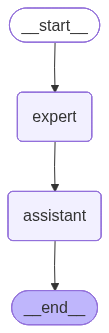

In [43]:
state_graph

In [44]:
response = state_graph.invoke(
    {"messages": [HumanMessage(content="What is class ?")]})

In [45]:
for message in response['messages']:
    print(message.content)

What is class ?
In the realm of software development, particularly in object-oriented programming (OOP), a **class** is a fundamental concept. Think of it as a **blueprint** or a **template** for creating objects.

Here's a breakdown of what a class is and its key characteristics:

**Analogy:**

Imagine you want to build several houses. Before you start building, you need a **blueprint**. This blueprint defines:

*   **What a house *is***: It has walls, a roof, doors, windows, etc.
*   **What a house *can do***: It can be opened, closed, painted, etc.
*   **What information a house *holds***: Its color, number of rooms, address, etc.

In this analogy:

*   The **blueprint** is the **class**.
*   Each individual **house** built from that blueprint is an **object** (or an instance of the class).

**Core Components of a Class:**

A class typically encapsulates two main things:

1.  **Attributes (or Properties, Data Members, Fields):**
    *   These represent the **data** or **state** that

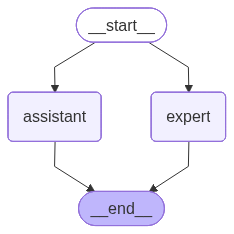

In [47]:
graph = StateGraph(MessagesState)

graph.add_node("expert", node_1)
graph.add_node("assistant", node_2)
graph.set_entry_point("expert")
graph.set_entry_point("assistant")
graph.set_finish_point("assistant")
graph.set_finish_point("expert")
state_graph = graph.compile()
state_graph

In [48]:
response = state_graph.invoke(
    {"messages": [HumanMessage(content="What is class ?")]})

for message in response['messages']:
    print(message.content)

What is class ?
In programming, a **class** is a blueprint or a template for creating objects. Think of it like a cookie cutter: the cookie cutter itself isn't a cookie, but it defines the shape and characteristics of all the cookies you can make with it.

Here's a breakdown of what a class represents and its key components:

**1. Blueprint/Template:**
*   A class defines the **properties** (data or attributes) and **behaviors** (methods or functions) that objects created from it will have.
*   It's a way to group related data and functionality together.

**2. Objects (Instances):**
*   When you create an actual "thing" from a class, that thing is called an **object** or an **instance** of the class.
*   Each object created from the same class will have the same structure (properties) and capabilities (behaviors), but they can have different values for their properties.

**Key Components of a Class:**

*   **Attributes (or Properties, Fields, Data Members):**
    *   These are variable

In [49]:
# Sample Structure used 

class ExtendedMessagesState(MessagesState):
    expert_one: str = "Software"
    expert_two: str = "Design"